In [1]:
import os

from tqdm.notebook import tqdm

import numpy as np
from matplotlib import pyplot as plt
from scipy.io import loadmat
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit
from scipy.special import erf

import kemstem

In [2]:
def calculate_R(raw_data, regressed):
    sse = np.sum(np.square(raw_data - regressed))
    sst = np.sum(np.square(raw_data - raw_data.mean()))
    return 1 - sse/sst

def fit(f, xdata, ydata, plot=False, **kwargs):
    xdata = np.array(xdata).flatten()
    ydata = np.array(ydata).flatten()
    if plot:
        plt.plot(xdata, ydata, 'k.')
        if 'sigma' in kwargs:
            plt.errorbar(xdata, ydata, kwargs['sigma'], fmt='none', c='k')
    popt, pcov = curve_fit(f, xdata, ydata, **kwargs)
    perr = np.sqrt(np.diag(pcov))
    R = calculate_R(ydata, f(xdata, *popt))
    if plot:
        xlim, ylim = plt.xlim(), plt.ylim()
        plt.xlim(*xlim)
        plt.ylim(*ylim)
        x = np.linspace(*xlim, 100)
        plt.plot(x, f(x, *popt), 'r--')
        plt.show()
    return popt, perr, R

In [3]:
results = {
    '2V': loadmat('./Si2V1-Niter1000.mat'),
    '5V': loadmat('./Si5V2-Niter1000.mat'),
    '8V': loadmat('./Si8V2-Niter1000.mat'),
    '30V': loadmat('./Si30V3-Niter1000.mat'),
}

In [4]:
DZ = {}
recons = {}

for key in results.keys():
    result = results[key]
    roi = result['p']['object_ROI'][0][0][0]
    roix = roi[0].T
    roiy = roi[1]

    DZ.update({key: result['outputs']['z_distance'].item().item()})
    recons.update({key: result['object'][roix, roiy]})

In [5]:
column_positions = {}

for key in results.keys():
    recon = recons[key]
    image = np.angle(recon[:,:,recon.shape[-1] // 2])
    blurred_image = gaussian_filter(image, 1)
    distance = 2
    threshold = 0.5
    c0 = kemstem.find_columns(blurred_image, distance=distance, threshold=threshold)

    column_positions.update({key: c0})

In [6]:
WINDOW = 1

column_lists = {}

for key in results.keys():

    c0 = column_positions[key]
    recon = recons[key]

    column_list = []
    for i, (cx, cy) in enumerate(tqdm(c0)):
        wx_start, wx_end = cx-WINDOW, cx+WINDOW+1
        wy_start, wy_end = cy-WINDOW, cy+WINDOW+1
        column = np.angle(recon)[wx_start:wx_end, wy_start:wy_end, 1:].mean(axis=(0, 1))
        column_list.append(column)

    column_lists.update({key: column_list})

  0%|          | 0/1464 [00:00<?, ?it/s]

  0%|          | 0/1004 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

  0%|          | 0/1014 [00:00<?, ?it/s]

In [7]:
def double_erf(x, p, q, x0, x1):
    return p * (erf(q*(x - x0)) - erf(q*(x - x1)))

def double_erf_plus_const(x, p0, p1, q, x0, x1):
    return p0 + double_erf(x, p1, q, x0, x1)

In [8]:
crystalline_heights = {}
crystalline_height_errs = {}

for key in results.keys():

    columns = column_lists[key]
    dz = DZ[key]

    crystalline = []
    crystalline_err = []

    for column in tqdm(columns):
        popt, perr, _ = fit(
            double_erf, np.arange(len(column)), column, plot=False,
            p0=[0.1,  0.3,  3, 12],
            # bounds=bounds,
            maxfev=10000
            )
        p1, q, x0, x1 = popt
        dp1, dq, dx0, dx1 = perr

        crystalline.append((x1 - x0) * dz)
        crystalline_err.append(dz * (dx0 + dx1) / 2)

    crystalline_heights.update({key: np.array(crystalline)})
    crystalline_height_errs.update({key: np.array(crystalline_err)})

  0%|          | 0/1464 [00:00<?, ?it/s]

  0%|          | 0/1004 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

  0%|          | 0/1014 [00:00<?, ?it/s]

In [9]:
safe_height_indices = {}

for key in results.keys():
    crystalline = crystalline_heights[key]
    crystalline_err = crystalline_height_errs[key]

    safe_height_index = np.where(crystalline_err < crystalline / 10)
    # safe_height_index = np.where(crystalline)
    safe_height_indices.update({key: safe_height_index})

In [10]:
for key, recon in recons.items():
    print(key)
    print(recon.shape[:-1])
    print([(recon.shape[0] * i) // 8 for i in [1, 3, 5, 7]])

2V
(573, 573)
[71, 214, 358, 501]
5V
(580, 580)
[72, 217, 362, 507]
8V
(581, 581)
[72, 217, 363, 508]
30V
(541, 541)
[67, 202, 338, 473]


In [11]:
thickness_rois = {
    '2V' : [[214, 358], [214, 358]],
    '5V' : [[217, 362], [ 72, 217]],
    '8V' : [[217, 363], [ 72, 217]],
    '30V': [[338, 473], [ 202, 338]]
}

In [12]:
roi_indices = {}

for key in results.keys():
    c0 = column_positions[key]
    indices = []
    (x0, x1), (y0, y1) = thickness_rois[key]
    idx = np.where(
        (c0[:,0] >= y0) & (c0[:,0] <= y1) & (c0[:,1] >= x0) & (c0[:,1] <= x1) 
    )
    indices.append(idx)
    roi_indices.update({key: indices})

In [13]:
roi_crystalline_height_means = {}
roi_crystalline_height_stds = {}
roi_amorphous_height_means = {}
roi_amorphous_height_stds = {}

for key in results.keys():

    safe_idx = safe_height_indices[key]
    roi_idx = roi_indices[key]
    total_thickness = recons[key].shape[-1] * DZ[key]

    idx = np.intersect1d(safe_idx, roi_idx)

    height = crystalline_heights[key]

    crystalline_mean = height[idx].mean()
    crystalline_std = height[idx].std()
    amorphous_mean = (total_thickness - crystalline_mean) / 2
    amorphous_std = crystalline_std / 2

    roi_crystalline_height_means.update({key: crystalline_mean})
    roi_crystalline_height_stds.update({key: crystalline_std})
    roi_amorphous_height_means.update({key: amorphous_mean})
    roi_amorphous_height_stds.update({key: amorphous_std})

In [14]:
# idx = np.where(crystalline_height_errs['2V'] > crystalline_heights['2V'] / 10)[0]

# if input(len(idx)) == 'y': pass

# for i in idx[::10]:
#     c = column_lists['2V'][i]
#     z = np.arange(len(c)) * DZ['2V']

#     popt, perr, _ = fit(
#         double_erf, np.arange(len(c)), c, plot=True,
#         p0=[0.28181914,  0.30406586,  3.74047066, 12.6762897],
#         # bounds=bounds,
#         maxfev=10000
#         )
    
#     p1, q, x0, x1 = popt
#     dp1, dq, dx0, dx1 = perr

#     print((x1 - x0) * dz, dz * (dx0 + dx1) / 2, (dz * (dx0 + dx1) / 2) /  (x1 - x0) * dz)

#     plt.show()

2V
Crystalline thickness: 179.520 ± 11.576
Amorphous thickness:    32.740 ±  5.788
(# of counted columns = 99/102)


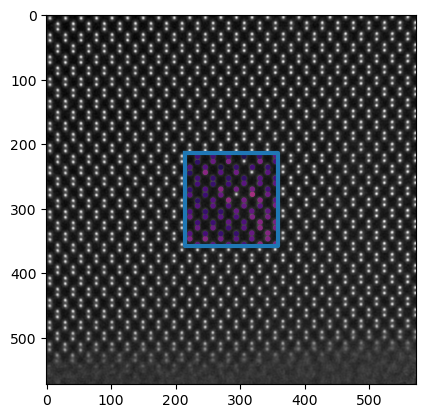

5V
Crystalline thickness: 159.217 ± 11.446
Amorphous thickness:    60.891 ±  5.723
(# of counted columns = 106/106)


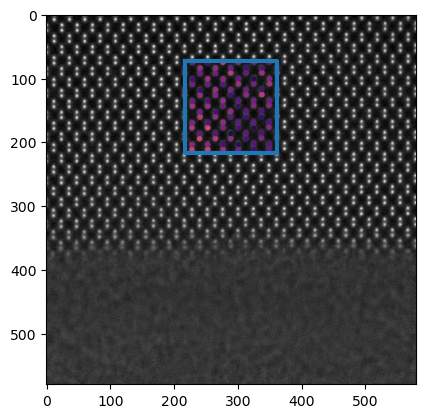

8V
Crystalline thickness: 185.428 ± 10.826
Amorphous thickness:    75.286 ±  5.413
(# of counted columns = 118/118)


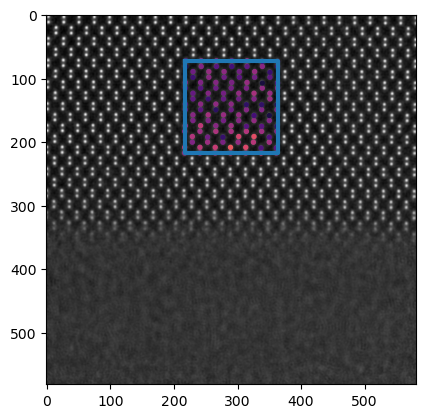

30V
Crystalline thickness: 156.487 ± 19.781
Amorphous thickness:    261.757 ±  9.891
(# of counted columns = 45/101)


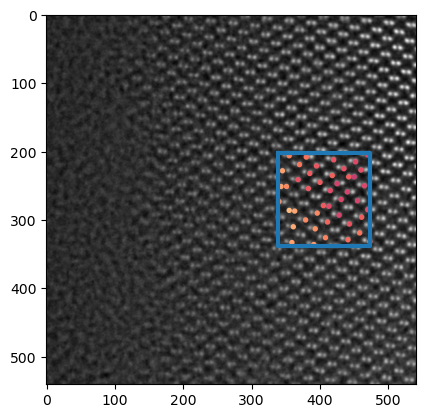

In [15]:
for key in results.keys():

    recon = recons[key]
    heights = crystalline_heights[key]
    c0 = column_positions[key]

    crystalline_mean = roi_crystalline_height_means[key]
    crystalline_std = roi_crystalline_height_stds[key]
    amorphous_mean = roi_amorphous_height_means[key]
    amorphous_std = roi_amorphous_height_stds[key]


    safe_idx = safe_height_indices[key]
    roi_idx = roi_indices[key]
    idx = np.intersect1d(safe_idx, roi_idx)

    print(key)
    print(f"Crystalline thickness: {crystalline_mean:.3f} ± {crystalline_std:.3f}")
    print(f"Amorphous thickness:    {amorphous_mean:.3f} ±  {amorphous_std:.3f}")
    print(f"(# of counted columns = {len(idx)}/{len(roi_idx[0][0])})")

    (x0, x1), (y0, y1) = thickness_rois[key]
    plt.imshow(np.angle(recon).sum(axis=-1), cmap='gray')
    plt.plot([x0, x0, x1, x1, x0], [y0, y1, y1, y0, y0], lw=3)

    # plt.axis('off')
    plt.scatter(
        c0[:, 1][idx], c0[:, 0][idx], c=np.array(heights)[idx], s=8, cmap='magma_r',
        vmin=heights[safe_idx].min(),
        vmax=heights[safe_idx].max()
        )
    # cbar = plt.colorbar()
    plt.show()


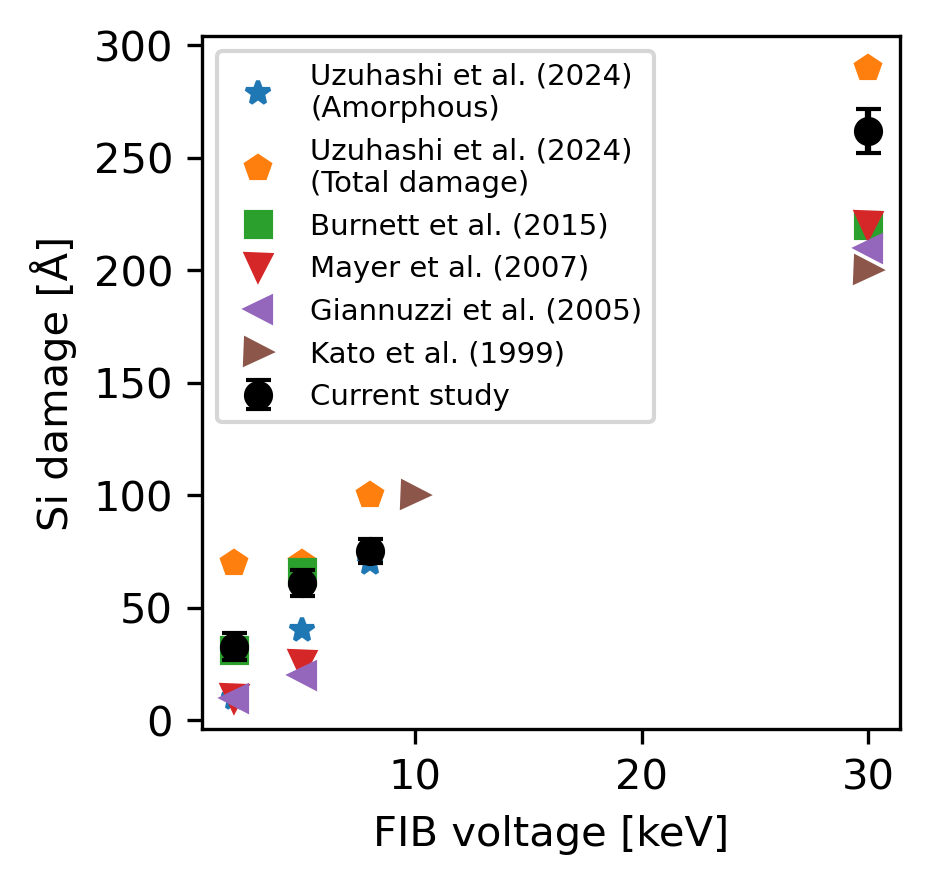

In [16]:
voltages = []
damage = []
damage_err = []

for key in results.keys():
    voltages.append(float(key[:-1]))
    damage.append(roi_amorphous_height_means[key])
    damage_err.append(roi_amorphous_height_stds[key])

plt.figure(figsize=(3, 3), dpi=300)

plt.errorbar(voltages, damage, damage_err,
    fmt="o", capsize=3, capthick=1, label="Current study",
    zorder=100, color='k'
    )
plt.plot([30, 8, 5, 2], [220, 70, 40, 10], '*', label='Uzuhashi et al. (2024)\n(Amorphous)')
plt.plot([30, 8, 5, 2], [290, 100, 70, 70], 'p', label='Uzuhashi et al. (2024)\n(Total damage)')
plt.plot([30, 5, 2], [220, 66, 31], 's', label='Burnett et al. (2015)')
plt.plot([30, 5, 2], [220, 25, 10], 'v', label='Mayer et al. (2007)')
plt.plot([30, 5, 2], [210, 20, 10], '<', label='Giannuzzi et al. (2005)')
plt.plot([30, 10], [200, 100], '>', label='Kato et al. (1999)')

plt.xlabel("FIB voltage [keV]")
plt.ylabel("Si damage [Å]")

plt.legend(fontsize=7)